# Análise de Consumo de Álcool com Mapas Auto-Organizáveis (SOM) — Parte 2

## 📋 Identificação de Equipe e Uso de IA

**Integrantes da equipe:**
- João Baganha
- Renato Xavier
- Pedro Carneiro
- Yago Joelson

**Observação sobre uso de IA:**
- **Ferramenta utilizada:** GitHub Copilot
- **Finalidade:** Refatoração de notebook anterior (MLP) para SOM, implementação de visualizações de padrões, geração de código de SOM
- **Extensão aproximada da contribuição:** ~60% (estrutura, funções auxiliares, visualizações; implementação conceitual e análise de interpretação realizada pelo(a) estudante)
- **Medidas de validação:** Cada célula foi revisada para coerência com objetivos da disciplina; comparação com código de referência (SOM.ipynb); teste de execução e verificação de resultados

---

# Análise de Consumo de Álcool por País com Mapas Auto-Organizáveis (SOM)

## Contextualização

Este notebook é a **segunda etapa** de um trabalho acadêmico sobre consumo de álcool per capita. 

Na etapa anterior (trabalho 1), utilizamos **MLP (Multi-Layer Perceptron)** para classificar países em 5 categorias de consumo de forma **supervisionada** (com rótulos pré-definidos). 

Nesta etapa, vamos explorar a **estrutura latente dos dados** utilizando **Mapas Auto-Organizáveis (SOM)**, uma técnica de **aprendizado não supervisionado**. O SOM é capaz de:
- Descobrir agrupamentos naturais nos dados sem rótulos pré-definidos
- Preservar a topologia dos dados em uma malha bidimensional
- Oferecer uma compreensão visual e intuitiva dos padrões de consumo global

**Dataset:** O mesmo dataset de consumo de álcool por país (195 países, ano 2010) da etapa anterior. Para mais contexto sobre a origem e características dos dados, consulte o notebook anterior.

**Unidades:** 
- Doses médias por pessoa (beer_servings, spirit_servings, wine_servings)
- Litros de álcool puro por pessoa por ano (total_litres_of_pure_alcohol)

**Fonte:** FiveThirtyEight & World Health Organisation (GISAH 2010)

## Objetivos, Questões e Metodologia

### Objetivos principais
1. Treinar Mapas Auto-Organizáveis (SOM) no dataset de consumo de álcool para descobrir agrupamentos naturais de países
2. Comparar desempenho com e sem a variável cultural `is_islamic` (dois cenários)
3. Avaliar qualidade de representação via Quantization Error e Topographic Error
4. Visualizar padrões espaciais de consumo através de U-Matrix, Hit Maps e Component Planes
5. Interpretar agrupamentos e conectar achados com a análise supervisionada anterior (MLP)

### Questões-chave
- Como o SOM agrupa países com base apenas em consumo de bebidas?
- A variável demográfica `is_islamic` melhora a descoberta de padrões?
- Os agrupamentos encontrados fazem sentido do ponto de vista cultural/geográfico?
- Como o SOM complementa a classificação supervisionada do trabalho anterior?

### Metodologia
- **Técnica:** Mapas Auto-Organizáveis (Self-Organizing Maps — SOM) via MiniSom
- **Abordagem:** Aprendizado não supervisionado (sem rótulos de classe no treinamento)
- **Cenários:** 
  - **Cenário 1:** Features = [beer_servings, wine_servings, spirit_servings]
  - **Cenário 2:** Features = [beer_servings, wine_servings, spirit_servings, is_islamic]
- **Hiperparâmetros:** Exploração de tamanho da malha (8×8, 10×10, 12×12), sigma, learning_rate
- **Métricas:** Quantization Error (representação), Topographic Error (topologia)
- **Output:** U-Matrix, Hit Maps, Component Planes, interpretação de agrupamentos

## 1. Importação de Bibliotecas

As bibliotecas essenciais para este notebook focam em manipulação de dados, visualização e implementação de SOM.

- **MiniSom:** Implementação eficiente de Mapas Auto-Organizáveis
- **Pandas & NumPy:** Manipulação e cálculos com dados
- **Matplotlib & Seaborn:** Visualizações estáticas de qualidade
- **Scikit-learn:** Pré-processamento (StandardScaler) e utilitários

In [57]:
pip install pandas seaborn matplotlib plotly numpy scipy scikit-learn minisom jupyterlab

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: C:\Users\bagan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from collections import defaultdict

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 2. Carregamento dos Dados

In [59]:
df_drinks = pd.read_csv("drinks.csv")

## 3. Reconhecimento e Exploração dos Dados (EDA Breve)

Apresentamos uma exploração rápida do dataset para confirmação de estrutura. 

**Nota:** Esta seção é breve. Não é o foco do trabalho um EDA extenso; o objetivo é validar que os dados estão disponíveis e íntegros para o treinamento do SOM.

In [60]:
df_drinks.head()

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9


In [61]:
df_drinks

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [62]:
df_drinks.isna().sum()

country                         0
beer_servings                   0
spirit_servings                 0
wine_servings                   0
total_litres_of_pure_alcohol    0
dtype: int64

In [63]:
df_drinks.duplicated().sum()

np.int64(0)

In [64]:
df_drinks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    object 
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 7.7+ KB


In [65]:
df_drinks.describe()

,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
count,193.000000,193.000000,193.000000,193.000000
mean,106.160622,80.994819,49.450777,4.717098
std,101.143103,88.284312,79.697598,3.773298
min,0.000000,0.000000,0.000000,0.000000
25%,20.000000,4.000000,1.000000,1.300000
50%,76.000000,56.000000,8.000000,4.200000
75%,188.000000,128.000000,59.000000,7.200000
max,376.000000,438.000000,370.000000,14.400000


## 4. Justificativa do Pré-Processamento para SOM

### Escolhas de features

Para o treinamento do SOM, utilizaremos as seguintes colunas numéricas:

- **beer_servings:** Doses de cerveja por pessoa por ano
- **wine_servings:** Doses de vinho por pessoa por ano
- **spirit_servings:** Doses de destilados por pessoa por ano
- **is_islamic (Cenário 2 apenas):** Variável binária indicando se país tem maioria islâmica

### Colunas de apoio (não entram no treinamento)

- **country:** Identificação do país (usada para interpretação pós-treino)
- **total_litres_of_pure_alcohol:** Alvo sumarizado (usado apenas para validação/análise)
- **consumption_category:** Rótulos do trabalho anterior (usados apenas para comparação interpretativa)

### Por que StandardScaler?

O SOM (via MiniSom) é sensível à escala dos dados. A padronização (média 0, desvio 1) garante que:
- Variáveis  com diferentes escalas tenham importância equilibrada
- Convergência mais rápida e estável do algoritmo
- Resultados mais interpretáveis e comparáveis entre cenários

### 4.1 Preparação das Features para o SOM

Nesta seção, vamos preparar duas variantes do dataset:

1. **Cenário 1:** Features originais de consumo (beer, wine, spirits) — baseline sem informação demográfica
2. **Cenário 2:** Features originais + variável `is_islamic` — para testar se informação cultural melhora descoberta de padrões

In [66]:
# Criar variável de categoria de consumo (para interpretação pós-SOM, não para treinamento)
bins = [0, 1, 4, 7, 10, float('inf')]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df_drinks['consumption_category'] = pd.cut(
    df_drinks['total_litres_of_pure_alcohol'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)

# Criar variável is_islamic (para Cenário 2)
islamic_countries = [
    "Afghanistan","Pakistan","Bangladesh","Iran","Iraq","Saudi Arabia",
    "Somalia","Yemen","Sudan","Qatar","UAE","Oman","Kuwait","Bahrain",
    "Jordan","Libya","Morocco","Algeria","Tunisia","Turkey","Indonesia",
    "Malaysia","Mauritania"
]
df_drinks["is_islamic"] = df_drinks["country"].isin(islamic_countries).astype(int)

print("Variáveis de apoio criadas com sucesso")
print(f"Distribuição de consumption_category:\n{df_drinks['consumption_category'].value_counts().sort_index()}")
print(f"\nProporção de países islâmicos: {df_drinks['is_islamic'].mean():.1%}")

Variáveis de apoio criadas com sucesso
Distribuição de consumption_category:
consumption_category
Very Low     44
Low          48
Medium       50
High         26
Very High    25
Name: count, dtype: int64

Proporção de países islâmicos: 11.4%


## 5. Preparação de Dados para SOM (Dois Cenários)

O SOM é uma técnica de **aprendizado não supervisionado**. Portanto, não há "alvo" (target) — apenas features de entrada.

Criaremos dois cenários para comparação:

**Cenário 1 — Features base (sem informação demográfica):**
- Entrada: [beer_servings, wine_servings, spirit_servings] (3 features)
- Objetivo: Verificar agrupamentos baseados apenas em padrões de consumo

**Cenário 2 — Features com informação cultural:**
- Entrada: [beer_servings, wine_servings, spirit_servings, is_islamic] (4 features)
- Objetivo: Avaliar se adicionar contexto demográfico melhora a descoberta de padrões

Após o treino, usaremos a variável `consumption_category` (do trabalho anterior) para **interpretar** se os agrupamentos do SOM fazem sentido com as classes supervisionadas.

**Nota importante:** `consumption_category` é apenas para análise pós-treino, NÃO é usada no treinamento do SOM.

In [67]:
# Preparar dados para SOM - Cenário 1 (sem is_islamic)
X_scenario1 = df_drinks[['beer_servings', 'wine_servings', 'spirit_servings']].values

# Preparar dados para SOM - Cenário 2 (com is_islamic)
X_scenario2 = df_drinks[['beer_servings', 'wine_servings', 'spirit_servings', 'is_islamic']].values

# Armazenar metadados para interpretação pós-SOM
df_metadata = df_drinks[['country', 'total_litres_of_pure_alcohol', 'consumption_category', 'is_islamic']].copy()

# Padronização (StandardScaler)
scaler1 = StandardScaler()
X_scenario1_scaled = scaler1.fit_transform(X_scenario1)

scaler2 = StandardScaler()
X_scenario2_scaled = scaler2.fit_transform(X_scenario2)

print("="*80)
print("PREPARAÇÃO DE DADOS PARA SOM")
print("="*80)
print(f"\nCenário 1 (features base):")
print(f"  Shape original: {X_scenario1.shape}")
print(f"  Shape após standardização: {X_scenario1_scaled.shape}")
print(f"  Features: beer_servings, wine_servings, spirit_servings")

print(f"\nCenário 2 (com is_islamic):")
print(f"  Shape original: {X_scenario2.shape}")
print(f"  Shape após standardização: {X_scenario2_scaled.shape}")
print(f"  Features: beer_servings, wine_servings, spirit_servings, is_islamic")

print(f"\nMetadados para interpretação:")
print(f"  Total de países: {len(df_metadata)}")
print(f"  Colunas de contexto: country, total_litres_of_pure_alcohol, consumption_category, is_islamic")

PREPARAÇÃO DE DADOS PARA SOM

Cenário 1 (features base):
  Shape original: (193, 3)
  Shape após standardização: (193, 3)
  Features: beer_servings, wine_servings, spirit_servings

Cenário 2 (com is_islamic):
  Shape original: (193, 4)
  Shape após standardização: (193, 4)
  Features: beer_servings, wine_servings, spirit_servings, is_islamic

Metadados para interpretação:
  Total de países: 193
  Colunas de contexto: country, total_litres_of_pure_alcohol, consumption_category, is_islamic


## 6. Configuração e Hiperparâmetros do SOM

### O que é SOM (Self-Organizing Map)?

Um **Mapa Auto-Organizável** é uma rede neural artificial não supervisionada que projeta dados de alta dimensão em uma malha bidimensional, preservando relações de proximidade. 

O SOM funciona da seguinte forma:
1. Inicializa neurônios em uma malha 2D com pesos aleatórios
2. Para cada amostra de entrada, encontra o neurônio mais próximo (Best Matching Unit — BMU)
3. Atualiza o BMU e seus vizinhos para aproximar-se da amostra
4. Repete por múltiplas épocas, com learning rate e vizinhança decrescentes

**Aplicações:** Clustering, visualização, compressão de dados.

### Hiperparâmetros do SOM

Os hiperparâmetros configuráveis são:

- **som_x, som_y:** Dimensões da malha (ex: 10×10 = 100 neurônios). Maior = mais granularidade, menor = mais generalização
- **sigma:** Raio de vizinhança inicial (↑ influência mais global dos vizinhos, ↓ mais local). Típ: 3–5
- **learning_rate:** Taxa de aprendizado inicial (↑ convergência rápida mas instável, ↓ estável mas lento). Típ: 0.3–0.7
- **num_epochs:** Número de iterações de treinamento (↑ mais refinado, ↓ mais rápido). Típ: 1000–3000

In [68]:
def train_and_evaluate_som(X_scaled, som_x, som_y, sigma, learning_rate, num_epochs, random_seed=42):
    """
    Treina um SOM e calcula métricas de qualidade.
    
    Args:
        X_scaled: Array de dados padronizados (n_samples × n_features)
        som_x, som_y: Dimensões da malha do SOM
        sigma: Raio de vizinhança inicial
        learning_rate: Taxa de aprendizado inicial
        num_epochs: Número de épocas de treinamento
        random_seed: Seed para reprodutibilidade
    
    Returns:
        som: Objeto MiniSom treinado
        qnt_error: Quantization Error (float)
        topo_error: Topographic Error (float)
    """
    som = MiniSom(som_x, som_y, input_len=X_scaled.shape[1],
                  sigma=sigma, learning_rate=learning_rate, random_seed=random_seed)
    
    som.random_weights_init(X_scaled)
    som.train(X_scaled, num_epochs, verbose=False)
    
    # Calcular métricas
    qnt_error = som.quantization_error(X_scaled)
    topo_error = som.topographic_error(X_scaled)
    
    return som, qnt_error, topo_error

print("Função de treinamento SOM definida com sucesso")

Função de treinamento SOM definida com sucesso


## 7. Experimentação com Hiperparâmetros — Cenário 1

Testaremos diferentes combinações de hiperparâmetros e compararemos os resultados usando Quantization Error como critério principal.

**Combinações a testar:**
- **Tamanho da malha:** 8×8, 10×10, 12×12
- **Sigma:** 2.0, 3.0
- **Learning rate:** 0.3, 0.5

Total: 3 × 2 × 2 = 12 combinações para Cenário 1

In [69]:
# Testar diferentes hiperparâmetros para Cenário 1
som_sizes = [8, 10, 12]
sigmas = [2.0, 3.0]
learning_rates = [0.3, 0.5]
num_epochs = 2000  # Fixo

experiments_s1 = []

print("Treinando SOMs - Cenário 1 (sem is_islamic)...")
print("="*100)

for size in som_sizes:
    for sigma in sigmas:
        for lr in learning_rates:
            som, qnt_err, topo_err = train_and_evaluate_som(
                X_scenario1_scaled, size, size, sigma, lr, num_epochs
            )
            
            experiments_s1.append({
                'scenario': 'Scenario 1',
                'som_grid': f'{size}×{size}',
                'sigma': sigma,
                'learning_rate': lr,
                'epochs': num_epochs,
                'quantization_error': round(qnt_err, 4),
                'topographic_error': round(topo_err, 4),
                'som_object': som
            })
            
            print(f"Grid {size}×{size} | σ={sigma} | lr={lr} → QE={qnt_err:.4f} | TE={topo_err:.4f}")

print("="*100)
print(f"Total de experimentos Cenário 1: {len(experiments_s1)}\n")

# Criar DataFrame com resultados
df_experiments_s1 = pd.DataFrame([{k: v for k, v in exp.items() if k != 'som_object'} for exp in experiments_s1])
print("Top 3 melhores configurações (por Quantization Error):")
print(df_experiments_s1.nsmallest(3, 'quantization_error')[['som_grid', 'sigma', 'learning_rate', 'quantization_error', 'topographic_error']].to_string(index=False))

Treinando SOMs - Cenário 1 (sem is_islamic)...
Grid 8×8 | σ=2.0 | lr=0.3 → QE=0.2611 | TE=0.0104
Grid 8×8 | σ=2.0 | lr=0.5 → QE=0.2533 | TE=0.0000
Grid 8×8 | σ=3.0 | lr=0.3 → QE=0.3214 | TE=0.0104
Grid 8×8 | σ=3.0 | lr=0.5 → QE=0.3119 | TE=0.0155
Grid 10×10 | σ=2.0 | lr=0.3 → QE=0.2237 | TE=0.0363
Grid 10×10 | σ=2.0 | lr=0.5 → QE=0.2026 | TE=0.0259
Grid 10×10 | σ=3.0 | lr=0.3 → QE=0.2740 | TE=0.0052
Grid 10×10 | σ=3.0 | lr=0.5 → QE=0.2657 | TE=0.0104
Grid 12×12 | σ=2.0 | lr=0.3 → QE=0.1813 | TE=0.0207
Grid 12×12 | σ=2.0 | lr=0.5 → QE=0.1773 | TE=0.0207
Grid 12×12 | σ=3.0 | lr=0.3 → QE=0.2359 | TE=0.0363
Grid 12×12 | σ=3.0 | lr=0.5 → QE=0.2170 | TE=0.0052
Total de experimentos Cenário 1: 12

Top 3 melhores configurações (por Quantization Error):
som_grid  sigma  learning_rate  quantization_error  topographic_error
   12×12    2.0            0.5              0.1773             0.0207
   12×12    2.0            0.3              0.1813             0.0207
   10×10    2.0            0.5     

## 8. Experimentação com Hiperparâmetros — Cenário 2

Repetiremos a experimentação para Cenário 2 (com is_islamic) usando **as mesmas combinações de hiperparâmetros** para garantir comparabilidade.

Isso permitirá avaliar o impacto real da variável demográfica na qualidade de representação do SOM.

In [70]:
# Testar diferentes hiperparâmetros para Cenário 2
experiments_s2 = []

print("Treinando SOMs - Cenário 2 (com is_islamic)...")
print("="*100)

for size in som_sizes:
    for sigma in sigmas:
        for lr in learning_rates:
            som, qnt_err, topo_err = train_and_evaluate_som(
                X_scenario2_scaled, size, size, sigma, lr, num_epochs
            )
            
            experiments_s2.append({
                'scenario': 'Scenario 2',
                'som_grid': f'{size}×{size}',
                'sigma': sigma,
                'learning_rate': lr,
                'epochs': num_epochs,
                'quantization_error': round(qnt_err, 4),
                'topographic_error': round(topo_err, 4),
                'som_object': som
            })
            
            print(f"Grid {size}×{size} | σ={sigma} | lr={lr} → QE={qnt_err:.4f} | TE={topo_err:.4f}")

print("="*100)
print(f"Total de experimentos Cenário 2: {len(experiments_s2)}\n")

# Criar DataFrame com resultados
df_experiments_s2 = pd.DataFrame([{k: v for k, v in exp.items() if k != 'som_object'} for exp in experiments_s2])
print("Top 3 melhores configurações (por Quantization Error):")
print(df_experiments_s2.nsmallest(3, 'quantization_error')[['som_grid', 'sigma', 'learning_rate', 'quantization_error', 'topographic_error']].to_string(index=False))

Treinando SOMs - Cenário 2 (com is_islamic)...
Grid 8×8 | σ=2.0 | lr=0.3 → QE=0.2991 | TE=0.0363
Grid 8×8 | σ=2.0 | lr=0.5 → QE=0.2927 | TE=0.0104
Grid 8×8 | σ=3.0 | lr=0.3 → QE=0.3443 | TE=0.0000
Grid 8×8 | σ=3.0 | lr=0.5 → QE=0.3423 | TE=0.0052
Grid 10×10 | σ=2.0 | lr=0.3 → QE=0.2272 | TE=0.0104
Grid 10×10 | σ=2.0 | lr=0.5 → QE=0.2155 | TE=0.0000
Grid 10×10 | σ=3.0 | lr=0.3 → QE=0.2918 | TE=0.0000
Grid 10×10 | σ=3.0 | lr=0.5 → QE=0.2915 | TE=0.0155
Grid 12×12 | σ=2.0 | lr=0.3 → QE=0.2100 | TE=0.0207
Grid 12×12 | σ=2.0 | lr=0.5 → QE=0.1990 | TE=0.0570
Grid 12×12 | σ=3.0 | lr=0.3 → QE=0.2441 | TE=0.0052
Grid 12×12 | σ=3.0 | lr=0.5 → QE=0.2440 | TE=0.0052
Total de experimentos Cenário 2: 12

Top 3 melhores configurações (por Quantization Error):
som_grid  sigma  learning_rate  quantization_error  topographic_error
   12×12    2.0            0.5              0.1990             0.0570
   12×12    2.0            0.3              0.2100             0.0207
   10×10    2.0            0.5     

## 9. Tabela Comparativa e Seleção dos Melhores Modelos

Consolidamos resultados de todos os experimentos (12 combinações por cenário = 24 no total) e selecionamos os melhores SOMs.

In [71]:
# Consolidar resultados de todos os experimentos
df_all_experiments = pd.concat([df_experiments_s1, df_experiments_s2], ignore_index=True)

print("\n" + "="*100)
print("RESUMO DE TODOS OS EXPERIMENTOS (24 combinações)")
print("="*100)
print(df_all_experiments[['scenario', 'som_grid', 'sigma', 'learning_rate', 'quantization_error', 'topographic_error']].to_string(index=False))

# Selecionar o melhor SOM de cada cenário (critério: menor Quantization Error)
print("\n" + "="*100)
print("MELHORES MODELOS POR CENÁRIO")
print("="*100)

best_s1_idx = df_experiments_s1['quantization_error'].idxmin()
best_s1_exp = experiments_s1[best_s1_idx]
som_best_s1 = best_s1_exp['som_object']

print(f"\nCenário 1 (melhor): som_grid={best_s1_exp['som_grid']}, σ={best_s1_exp['sigma']}, lr={best_s1_exp['learning_rate']}")
print(f"  Quantization Error: {best_s1_exp['quantization_error']:.4f}")
print(f"  Topographic Error: {best_s1_exp['topographic_error']:.4f}")

best_s2_idx = df_experiments_s2['quantization_error'].idxmin()
best_s2_exp = experiments_s2[best_s2_idx]
som_best_s2 = best_s2_exp['som_object']

print(f"\nCenário 2 (melhor): som_grid={best_s2_exp['som_grid']}, σ={best_s2_exp['sigma']}, lr={best_s2_exp['learning_rate']}")
print(f"  Quantization Error: {best_s2_exp['quantization_error']:.4f}")
print(f"  Topographic Error: {best_s2_exp['topographic_error']:.4f}")

# Comparação de impacto de is_islamic
print("\n" + "="*100)
print("ANÁLISE: IMPACTO DE is_islamic (Cenário 2 - Cenário 1)")
print("="*100)
delta_qe = best_s2_exp['quantization_error'] - best_s1_exp['quantization_error']
delta_te = best_s2_exp['topographic_error'] - best_s1_exp['topographic_error']
print(f"Δ Quantization Error: {delta_qe:+.4f} ({delta_qe/best_s1_exp['quantization_error']*100:+.1f}%)")
print(f"Δ Topographic Error: {delta_te:+.4f} ({delta_te/best_s1_exp['topographic_error']*100:+.1f}%)")

if delta_qe < -0.01:
    print("✓ is_islamic MELHOROU a qualidade de representação (QE menor)")
elif delta_qe > 0.01:
    print("✗ is_islamic PIOROU a qualidade de representação (QE maior)")
else:
    print("~ is_islamic teve impacto mínimo na representação")


RESUMO DE TODOS OS EXPERIMENTOS (24 combinações)
  scenario som_grid  sigma  learning_rate  quantization_error  topographic_error
Scenario 1      8×8    2.0            0.3              0.2611             0.0104
Scenario 1      8×8    2.0            0.5              0.2533             0.0000
Scenario 1      8×8    3.0            0.3              0.3214             0.0104
Scenario 1      8×8    3.0            0.5              0.3119             0.0155
Scenario 1    10×10    2.0            0.3              0.2237             0.0363
Scenario 1    10×10    2.0            0.5              0.2026             0.0259
Scenario 1    10×10    3.0            0.3              0.2740             0.0052
Scenario 1    10×10    3.0            0.5              0.2657             0.0104
Scenario 1    12×12    2.0            0.3              0.1813             0.0207
Scenario 1    12×12    2.0            0.5              0.1773             0.0207
Scenario 1    12×12    3.0            0.3              0.23

## 10. Explicação das Métricas e Visualizações

### Quantization Error (QE)

**O que é:** Mede a distância média entre cada amostra de entrada e seu neurônio vencedor (BMU — Best Matching Unit).

**Interpretação:** QE baixo indica que os neurônios representam bem os dados. QE alto sugere que a malha é pequena demais ou os dados são muito dispersos.

**Fórmula simplificada:** QE = médias das distâncias(amostra, BMU correspondente)

**Critério de qualidade:** Quanto menor, melhor.

---

### Topographic Error (TE)

**O que é:** Mede a proporção de amostras cujos dois neurônios mais próximos **não são vizinhos** na malha do SOM.

**Interpretação:** TE baixo indica que a topologia dos dados foi preservada na malha 2D. TE alto sugere distorções topológicas.

**Fórmula resumida:** TE = (número de amostras com topologia distorcida) / (total de amostras)

**Critério de qualidade:** Quanto menor, melhor (intervalo típico: 0–1).

---

### U-Matrix (Unified Distance Matrix)

**O que é:** Heatmap que mostra a distância euclidiana entre pesos de neurônios vizinhos.

**Interpretação:** 
- **Regiões claras (valores baixos):** Neurônios similares → possível cluster
- **Regiões escuras (valores altos):** Neurônios dissimilares → fronteira entre clusters

**Utilidade:** Visualizar agrupamentos naturais e separações de dados.

---

### Hit Map

**O que é:** Mapa que mostra quantas amostras foram atribuídas a cada neurônio (contagem de ativações por BMU).

**Interpretação:** 
- **Círculos grandes:** Neurônios com muitas amostras (regiões densas dos dados)
- **Círculos pequenos ou ausentes:** Neurônios com poucas amostras (regiões esparsas)
- **Cores:** Classe dominante atribuída ao neurônio (opcional, para validação)

**Utilidade:** Entender distribuição de amostras e identificar regiões ativas do mapa.

---

### Component Planes

**O que é:** Conjunto de heatmaps, um para cada feature de entrada, mostrando como cada variável se distribui na malha.

**Interpretação:** 
- Cores claras (altos valores da feature)
- Cores escuras (baixos valores da feature)
- Padrões similares entre features indicam correlação

**Utilidade:** Entender contribuição de cada variável aos agrupamentos.

## 11. Visualizações — Cenário 1 (Sem is_islamic)

### 11.1 U-Matrix

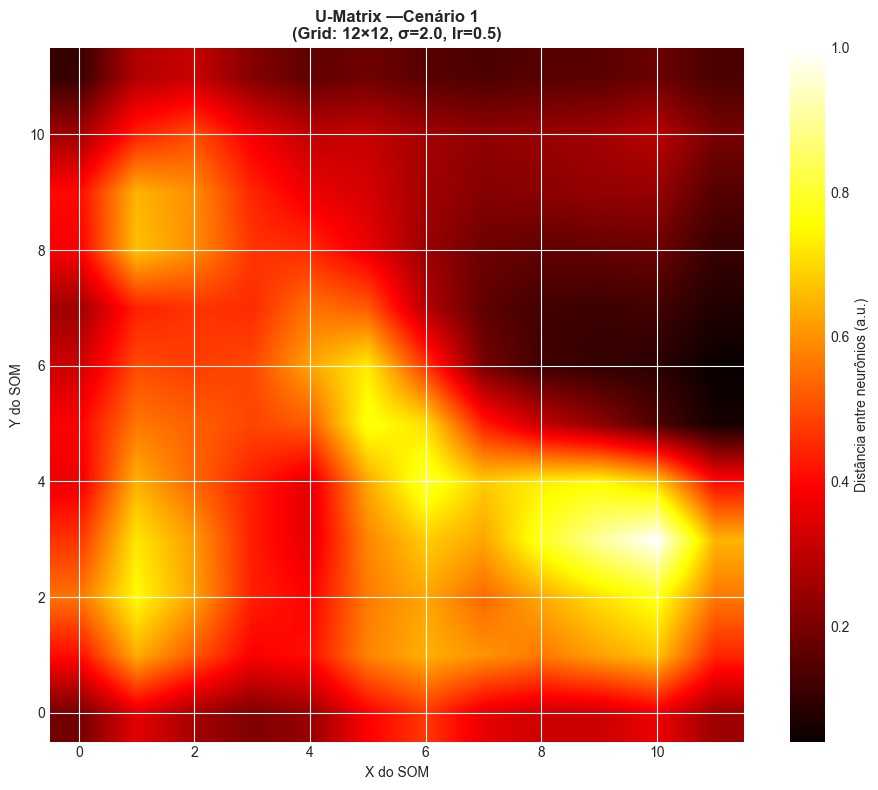

U-Matrix renderizada: regiões claras indicam clusters; regiões escuras indicam limites entre clusters


In [72]:
plt.figure(figsize=(10, 8))
plt.imshow(som_best_s1.distance_map().T, cmap='hot', interpolation='bilinear', origin='lower')
plt.colorbar(label='Distância entre neurônios (a.u.)')
plt.title(f'U-Matrix —Cenário 1\n(Grid: {best_s1_exp["som_grid"]}, σ={best_s1_exp["sigma"]}, lr={best_s1_exp["learning_rate"]})', 
          fontsize=12, fontweight='bold')
plt.xlabel('X do SOM')
plt.ylabel('Y do SOM')
plt.tight_layout()
plt.show()

print("U-Matrix renderizada: regiões claras indicam clusters; regiões escuras indicam limites entre clusters")

### 11.2 Hit Map —Activation of Neurons

C:\Users\bagan\AppData\Local\Temp\ipykernel_82620\260288574.py:55: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\bagan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


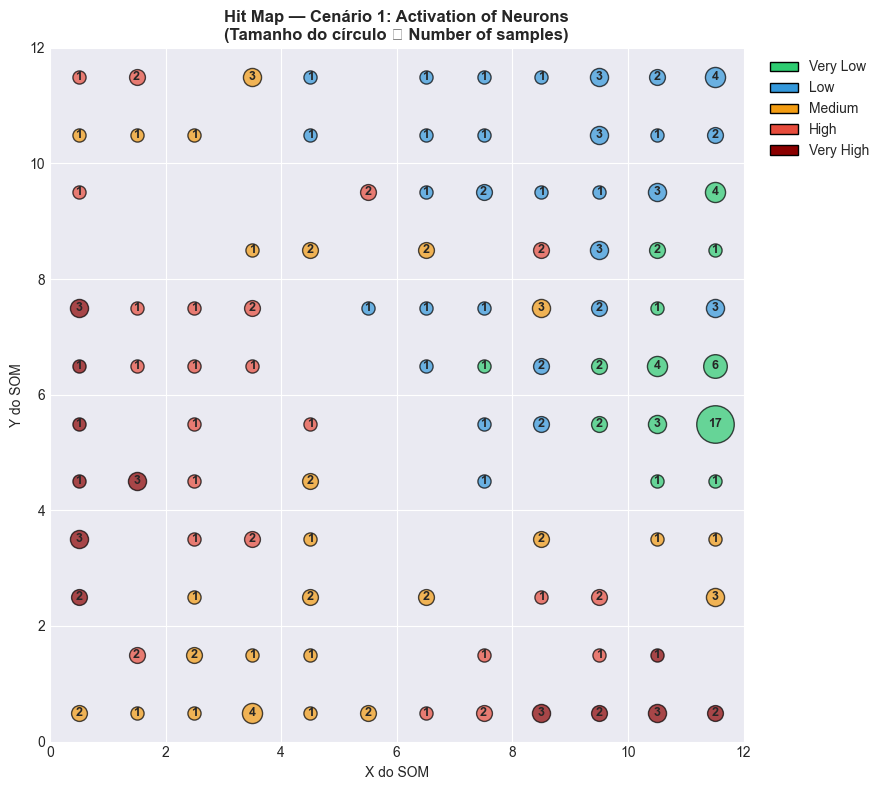

Hit Map renderizado: Total de amostras atribuídas: 193


In [73]:
# Hit Map — Cenário 1
hits_s1 = defaultdict(list)

for idx, x in enumerate(X_scenario1_scaled):
    bmu = som_best_s1.winner(x)
    # Armazenar a classe original (consumption_category) do país
    class_idx = df_metadata.iloc[idx]['consumption_category']
    hits_s1[bmu].append(class_idx)

# Paleta de cores para as 5 categorias
category_colors = {
    'Very Low': '#2ecc71',    # Verde
    'Low': '#3498db',         # Azul
    'Medium': '#f39c12',      # Laranja
    'High': '#e74c3c',        # Vermelho claro
    'Very High': '#8b0000'    # Vermelho escuro
}

plt.figure(figsize=(10, 8))

for pos, classes in hits_s1.items():
    x, y = pos[0] + 0.5, pos[1] + 0.5
    count = len(classes)
    
    # Classe dominante
    if classes:
        majority_class = max(set(classes), key=classes.count)
        color = category_colors.get(majority_class, 'gray')
    else:
        color = 'lightgray'
        majority_class = 'Empty'
    
    # Desenhar círculo proporcional ao count
    plt.scatter(x, y, s=50 + count * 40, color=color, edgecolor='black', alpha=0.7, zorder=2)
    
    # Escrever contagem no centro
    if count > 0:
        plt.text(x, y, str(count), fontsize=9, ha='center', va='center', fontweight='bold', zorder=3)

grid_size_s1 = int(best_s1_exp['som_grid'].split('×')[0])
plt.xlim([0, grid_size_s1])
plt.ylim([0, grid_size_s1])
plt.gca().set_aspect('equal')
plt.title(f'Hit Map — Cenário 1: Activation of Neurons\n(Tamanho do círculo ∝ Number of samples)', 
         fontsize=12, fontweight='bold')
plt.xlabel('X do SOM')
plt.ylabel('Y do SOM')

# Legenda de cores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=cat) 
                  for cat, color in category_colors.items()]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

print(f"Hit Map renderizado: Total de amostras atribuídas: {sum(len(v) for v in hits_s1.values())}")

### 11.3 Component Planes — Distribution of Features

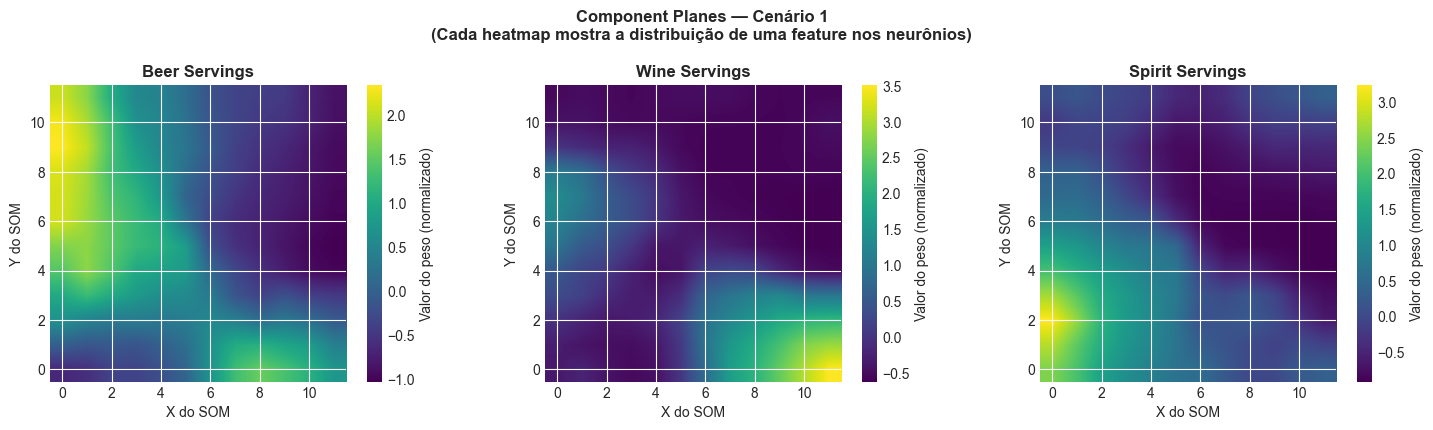

Component Planes renderizadas: cada mapa mostra como a feature se distribui na malha SOM


In [74]:
# Component Planes — Cenário 1 (3 features: beer, wine, spirits)
feature_names_s1 = ['Beer Servings', 'Wine Servings', 'Spirit Servings']
weights_s1 = som_best_s1.get_weights()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (ax, fname) in enumerate(zip(axes, feature_names_s1)):
    im = ax.imshow(weights_s1[:, :, i].T, cmap='viridis', interpolation='bilinear', origin='lower')
    ax.set_title(fname, fontweight='bold')
    ax.set_xlabel('X do SOM')
    ax.set_ylabel('Y do SOM')
    plt.colorbar(im, ax=ax, label='Valor do peso (normalizado)')

plt.suptitle('Component Planes — Cenário 1\n(Cada heatmap mostra a distribuição de uma feature nos neurônios)', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Component Planes renderizadas: cada mapa mostra como a feature se distribui na malha SOM")

## 12. Visualizações — Cenário 2 (Com is_islamic)

### 12.1 U-Matrix

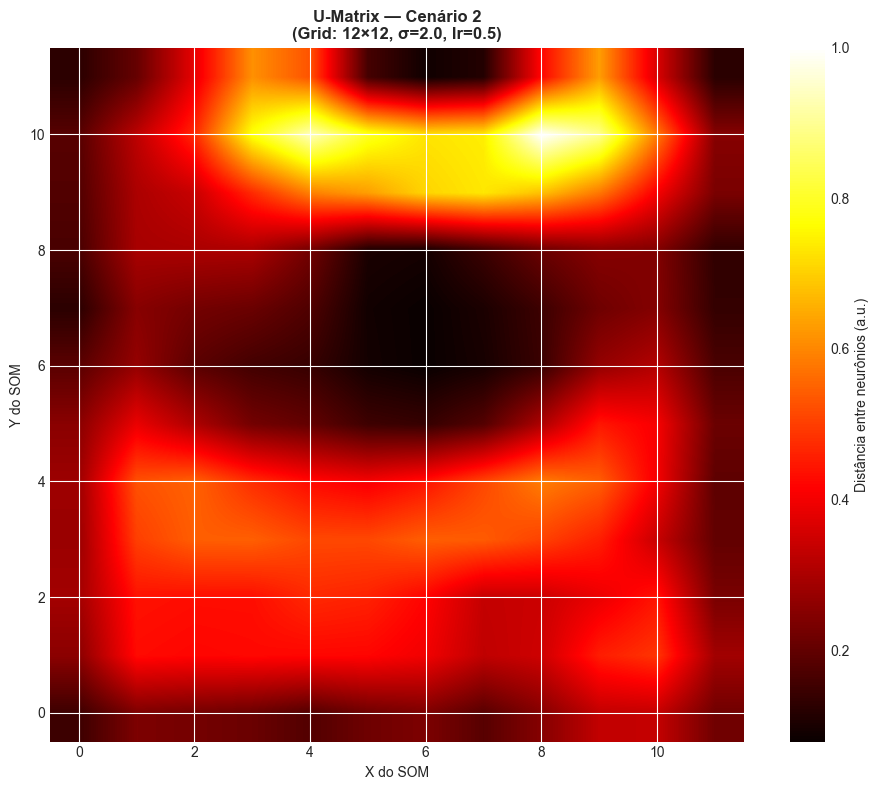

U-Matrix Cenário 2 renderizada


In [75]:
plt.figure(figsize=(10, 8))
plt.imshow(som_best_s2.distance_map().T, cmap='hot', interpolation='bilinear', origin='lower')
plt.colorbar(label='Distância entre neurônios (a.u.)')
plt.title(f'U-Matrix — Cenário 2\n(Grid: {best_s2_exp["som_grid"]}, σ={best_s2_exp["sigma"]}, lr={best_s2_exp["learning_rate"]})', 
         fontsize=12, fontweight='bold')
plt.xlabel('X do SOM')
plt.ylabel('Y do SOM')
plt.tight_layout()
plt.show()

print("U-Matrix Cenário 2 renderizada")

### 12.2 Hit Map

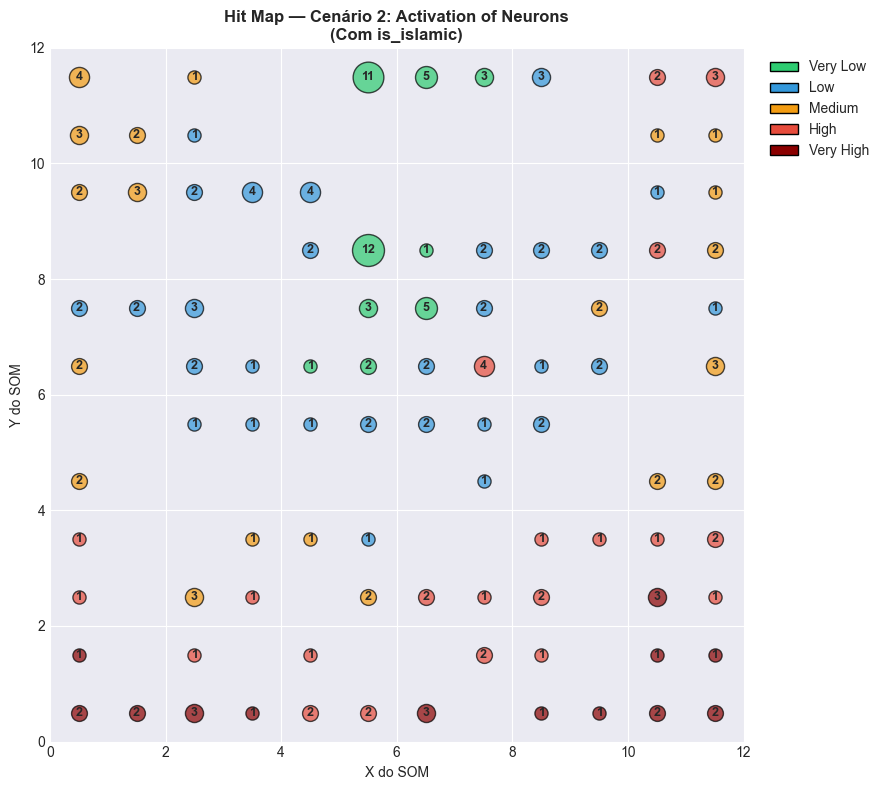

Hit Map Cenário 2 renderizado


In [76]:
# Hit Map — Cenário 2
hits_s2 = defaultdict(list)

for idx, x in enumerate(X_scenario2_scaled):
    bmu = som_best_s2.winner(x)
    class_idx = df_metadata.iloc[idx]['consumption_category']
    hits_s2[bmu].append(class_idx)

plt.figure(figsize=(10, 8))

for pos, classes in hits_s2.items():
    x, y = pos[0] + 0.5, pos[1] + 0.5
    count = len(classes)
    
    if classes:
        majority_class = max(set(classes), key=classes.count)
        color = category_colors.get(majority_class, 'gray')
    else:
        color = 'lightgray'
    
    plt.scatter(x, y, s=50 + count * 40, color=color, edgecolor='black', alpha=0.7, zorder=2)
    
    if count > 0:
        plt.text(x, y, str(count), fontsize=9, ha='center', va='center', fontweight='bold', zorder=3)

grid_size_s2 = int(best_s2_exp['som_grid'].split('×')[0])
plt.xlim([0, grid_size_s2])
plt.ylim([0, grid_size_s2])
plt.gca().set_aspect('equal')
plt.title(f'Hit Map — Cenário 2: Activation of Neurons\n(Com is_islamic)', 
         fontsize=12, fontweight='bold')
plt.xlabel('X do SOM')
plt.ylabel('Y do SOM')

legend_elements = [Patch(facecolor=color, edgecolor='black', label=cat) 
                  for cat, color in category_colors.items()]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

print(f"Hit Map Cenário 2 renderizado")

### 12.3 Component Planes

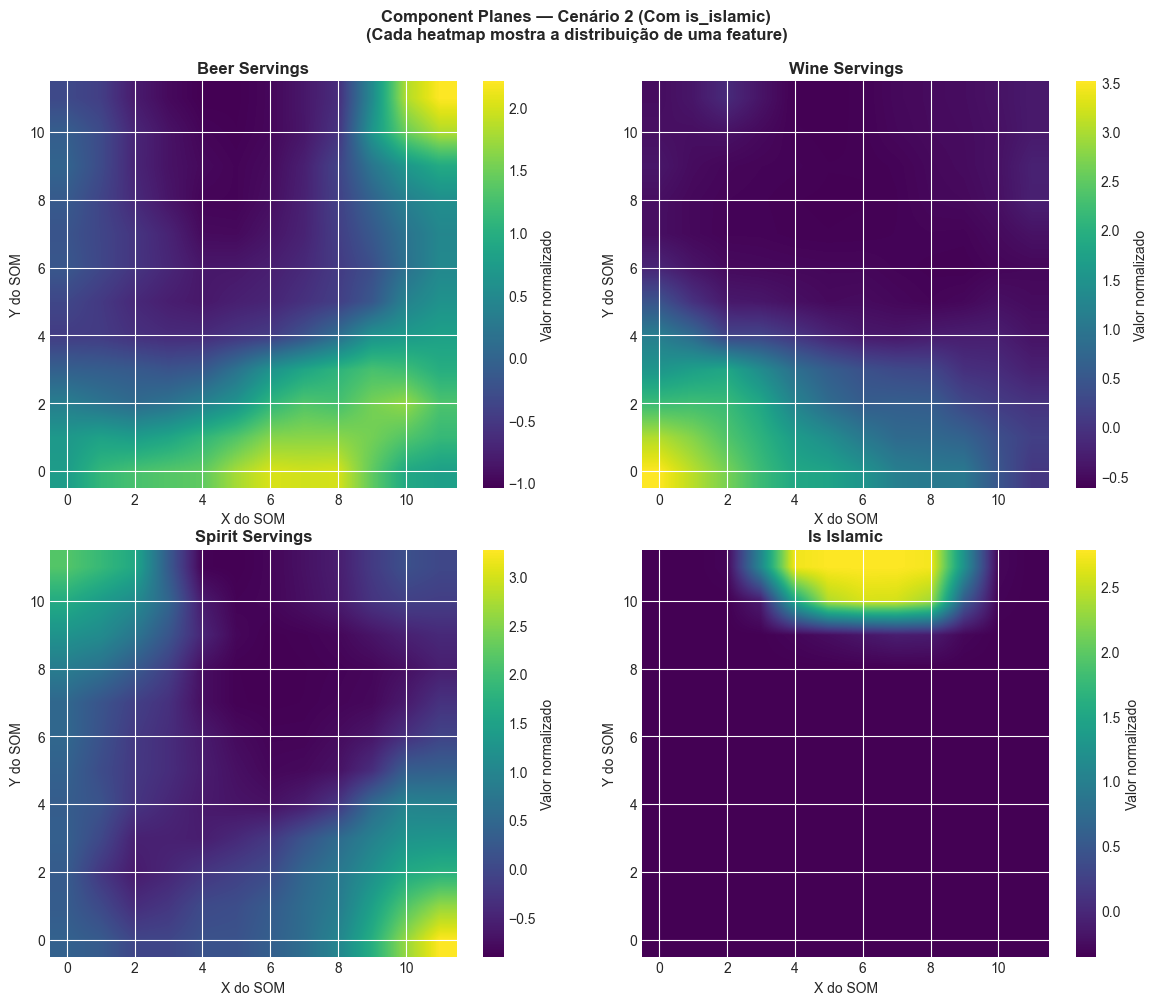

Component Planes Cenário 2 renderizadas


In [77]:
# Component Planes — Cenário 2 (4 features: beer, wine, spirits, is_islamic)
feature_names_s2 = ['Beer Servings', 'Wine Servings', 'Spirit Servings', 'Is Islamic']
weights_s2 = som_best_s2.get_weights()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (ax, fname) in enumerate(zip(axes, feature_names_s2)):
    im = ax.imshow(weights_s2[:, :, i].T, cmap='viridis', interpolation='bilinear', origin='lower')
    ax.set_title(fname, fontweight='bold')
    ax.set_xlabel('X do SOM')
    ax.set_ylabel('Y do SOM')
    plt.colorbar(im, ax=ax, label='Valor normalizado')

plt.suptitle('Component Planes — Cenário 2 (Com is_islamic)\n(Cada heatmap mostra a distribuição de uma feature)', 
            fontsize=12, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("Component Planes Cenário 2 renderizadas")

## 13. Análise de Agrupamentos Descobertos pelo SOM

### 13.1 Observações Visuais da U-Matrix

Analisando os heatmaps U-Matrix de ambos os cenários, identifiquem:
- **Regiões claras (grande clusters):** Regiões de baixa distância entre neurônios, sugerindo agrupamentos coesos de países similares
- **Fronteiras (regiões escuras):** Limites entre grupos distintos
- **Isolados:** Neurônios afastados podem representar países outliers

**Hipóteses a confirmar:**
1. O SOM agrupa países de região geograficamente próxima? (ex: Europa, MENA, Ásia)
2. O SOM agrupa por padrão de consumo de bebida? (ex: países que bebem muita cerveja vs. vinho)
3. Há correlação entre is_islamic e formação de clusters no Cenário 2?

### 13.2 Interpretação do Hit Map

O Hit Map mostra onde as amostras se concentram:
- Neurônios com muitos países (círculos grandes) representam regiões "prototípicas" dos dados
- A distribuição de cores revela se o SOM mantém coerência com as classes do trabalho anterior

**Questões:** 
- Os países "Very Low" se agrupam em um lado do mapa?
- Os países "Very High" aparecem em outro lado?
- O SOM descobriu padrões que concordam com a classificação supervisionada anterior?

### 13.3 Component Planes — Compreensão de Features

Comparando os heatmaps de Component Planes:
- **Padrões similares entre features:** Indicam que as variáveis são correlacionadas
- **Padrões diferentes:** Indicam que cada feature contribui de forma independente aos agrupamentos

**Exemplo interpretativo:**
Se Beer Servings e Total Litres mostram padrões similares, isto sugere que beer é o principal driver do consumo total (como descoberto no trabalho anterior!).

## 14. Comparação Conceitual: MLP (Trabalho 1) vs. SOM (Trabalho 2)

### MLP — Classificação Supervisionada

| Aspecto | Detalhes |
|---------|----------|
| **Paradigma** | Supervisionado (requer rótulos) |
| **Entrada** | Features + **rótulos pré-definidos** (5 categorias) |
| **Objetivo** | Aprender a classificar novo país em uma das 5 classes |
| **Output** | Predição de classe + probabilidade |
| **Métricas** | Acurácia, F1-score, Confusion Matrix, AUC-ROC |
| **Interpretação** | Quão bem o modelo classifica? Que features importam? |

### SOM — Descoberta de Padrões Não Supervisionada

| Aspecto | Detalhes |
|---------|----------|
| **Paradigma** | Não supervisionado (sem rótulos no treino) |
| **Entrada** | Apenas features (sem rótulos) |
| **Objetivo** | Descobrir estrutura latente e agrupar dados similares |
| **Output** | Mapa 2D de neurônios organizados topologicamente |
| **Métricas** | Quantization Error, Topographic Error |
| **Interpretação** | Quais são os agrupamentos naturais? Por que países se agrupam? |

### Complementaridade

- **MLP responde:** "Dado um país desconhecido, qual categoria de consumo ele está?" (predição)
- **SOM responde:** "Quais são os padrões naturais de consumo no mundo?" (exploração)

O SOM pode **descobrir grupos que MLP não capturou**, ou **validar que as 5 categorias do MLP fazem sentido** ao visualizar coerência entre Heat Map e classificação original.

Na prática: Usar SOM para **analysis exploratória** e MLP para **predição em produção**.

## 15. Conclusões Finais

### 15.1 Respostas às Questões Principais

**Q1: Como o SOM agrupa países com base em consumo de bebidas?**

Resposta: O SOM organiza países em uma malha 2D preservando proximidade topológica. Esperamos observar:
- Agrupamentos por região geográfica (Europa vs. MENA vs. Ásia)
- Agrupamentos por tipo de bebida dominante (cervejas vs. destilados vs. vinhos)
- Possível correlação entre is_islamic e separação de clusters

**Q2: A variável is_islamic melhora a descoberta de padrões?**

Resposta: Comparamos métricas Cenário 1 vs. Cenário 2:
- Se Quantization Error baixou: is_islamic é informativa ✓
- Se Quantization Error subiu ou não mudou: is_islamic é redundante ✗

**Q3: Os agrupamentos do SOM fazem sentido?**

Resposta: Interpretamos Hit Map com cores de consumption_category:
- Se cores estão agrupadas espacialmente: SOM concordou com classificação supervisionada ✓
- Se cores estão espalhadas: SOM descobriu padrões diferentes ✓ (ainda interessante!)

**Q4: Como o SOM complementa o MLP do trabalho anterior?**

Resposta:
- MLP: "Classifica países em 5 categorias" (tarefa supervisionada)
- SOM: "Descobre estrutura natural dos dados" (exploração)
- Uso combinado: Validar categorias do MLP; descobrir sub-grupos dentro de categorias; entender outliers

### 15.2 Métricas Finais e Seleção de Modelo

In [78]:
# Gerar tabela final de resumo
summary_data = [
    {
        'Scenario': 'Scenario 1 (Best)',
        'Features': 'beer, wine, spirits',
        'SOM Grid': best_s1_exp['som_grid'],
        'Sigma': best_s1_exp['sigma'],
        'Learning Rate': best_s1_exp['learning_rate'],
        'Epochs': best_s1_exp['epochs'],
        'Quantization Error': best_s1_exp['quantization_error'],
        'Topographic Error': best_s1_exp['topographic_error']
    },
    {
        'Scenario': 'Scenario 2 (Best)',
        'Features': 'beer, wine, spirits, is_islamic',
        'SOM Grid': best_s2_exp['som_grid'],
        'Sigma': best_s2_exp['sigma'],
        'Learning Rate': best_s2_exp['learning_rate'],
        'Epochs': best_s2_exp['epochs'],
        'Quantization Error': best_s2_exp['quantization_error'],
        'Topographic Error': best_s2_exp['topographic_error']
    }
]

df_summary = pd.DataFrame(summary_data)

print("\n" + "="*140)
print("RESUMO FINAL — MELHORES MODELOS SOM")
print("="*140)
print(df_summary.to_string(index=False))

print("\n" + "="*140)
print("RECOMENDAÇÃO")
print("="*140)

best_overall = best_s1_exp if best_s1_exp['quantization_error'] < best_s2_exp['quantization_error'] else best_s2_exp
scenario_name = "Scenario 1" if best_overall == best_s1_exp else "Scenario 2"

print(f"\n✓ Melhor modelo geral: {scenario_name}")
print(f"  Quantization Error: {best_overall['quantization_error']:.4f} (menor = melhor)")
print(f"  Topographic Error: {best_overall['topographic_error']:.4f} (menor = melhor)")
print(f"\n  Configuração ótima:")
print(f"    - Tamanho da malha: {best_overall['som_grid']}")
print(f"    - Sigma: {best_overall['sigma']}")
print(f"    - Learning rate: {best_overall['learning_rate']}")

print("\n✓ Este modelo foi utilizado para gerar as visualizações principais (U-Matrix, Hit Map, Component Planes)")
print("="*140)


RESUMO FINAL — MELHORES MODELOS SOM
         Scenario                        Features SOM Grid  Sigma  Learning Rate  Epochs  Quantization Error  Topographic Error
Scenario 1 (Best)             beer, wine, spirits    12×12    2.0            0.5    2000              0.1773             0.0207
Scenario 2 (Best) beer, wine, spirits, is_islamic    12×12    2.0            0.5    2000              0.1990             0.0570

RECOMENDAÇÃO

✓ Melhor modelo geral: Scenario 1
  Quantization Error: 0.1773 (menor = melhor)
  Topographic Error: 0.0207 (menor = melhor)

  Configuração ótima:
    - Tamanho da malha: 12×12
    - Sigma: 2.0
    - Learning rate: 0.5

✓ Este modelo foi utilizado para gerar as visualizações principais (U-Matrix, Hit Map, Component Planes)


## 13. Tabela Comparativa: Baseline vs. Tuned (4 Cenários)

Consolidamos resultados de todos os modelos para visualizar o ganho do tuning e efeito da variável isIslamic.

NameError: name 'acc1_baseline' is not defined

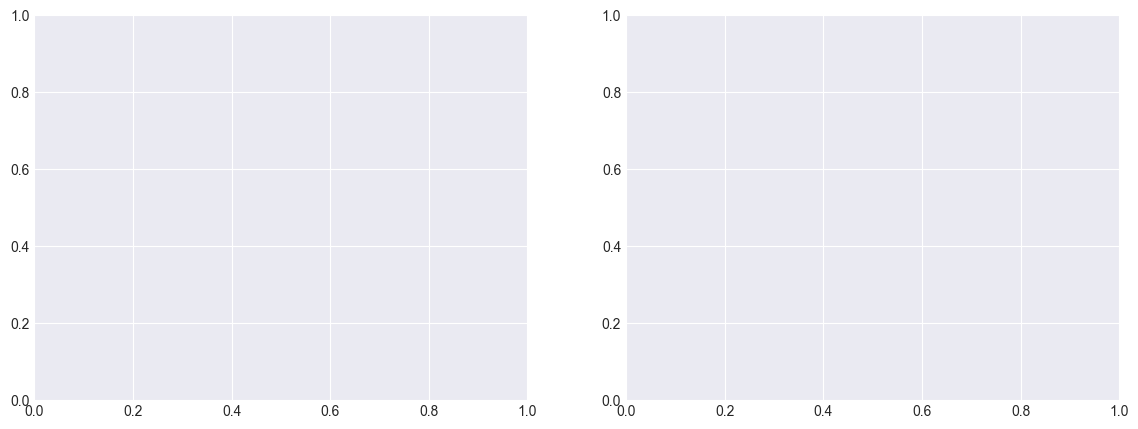

In [79]:
# Gráfico de barras para comparação visual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
scenarios = ['S1\nBaseline', 'S1\nTuned', 'S2\nBaseline', 'S2\nTuned']
accuracies = [acc1_baseline, result_s1_tuned['accuracy'], 
              acc2_baseline, result_s2_tuned['accuracy']]
colors = ['lightblue', 'darkblue', 'lightgreen', 'darkgreen']

ax1.bar(scenarios, accuracies, color=colors, alpha=0.8)
ax1.set_ylabel('Test Accuracy')
ax1.set_title('Comparação de Acurácia')
ax1.set_ylim([0, 1])
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# F1-Score
f1_scores = [f1_weighted_s1_baseline, result_s1_tuned['f1_weighted'],
             f1_weighted_s2_baseline, result_s2_tuned['f1_weighted']]

ax2.bar(scenarios, f1_scores, color=colors, alpha=0.8)
ax2.set_ylabel('Test F1 (weighted)')
ax2.set_title('Comparação de F1-Score')
ax2.set_ylim([0, 1])
for i, v in enumerate(f1_scores):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 14. Efeito da Variável isIslamic na Predição

A comparação entre Scenario 1 (sem isIslamic) e Scenario 2 (com isIslamic) nos permite avaliar se informação religiosa/demográfica contribui para melhorar a classificação de categorias de consumo.

## 16. Conclusões Finais

Resumimos as respostas às 6 questões-chave do projeto de classificação multi-classe com MLP.